In [45]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

Generate a graph

<Figure size 400x400 with 0 Axes>

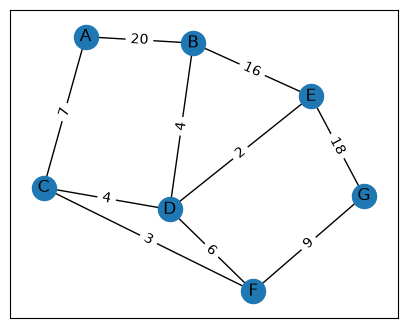

In [46]:
fig = plt.figure(figsize=(4,4))
G = nx.Graph()
G.add_node('A', pos="1,3!", demand=-10)
G.add_node('B', pos="3,5!")
G.add_node('C', pos="3,1!")
G.add_node('D', pos="4,2!")
G.add_node('E', pos="5,5!")
G.add_node('F', pos="5,1!")
G.add_node('G', pos="7,3!", demand=10)

G.add_edge('A','B',weight=20)
G.add_edge('A','C',weight=7)
G.add_edge('B','E',weight=16)
G.add_edge('B','D',weight=4)
G.add_edge('C','F',weight=3)
G.add_edge('C','D',weight=4)
G.add_edge('D','E',weight=2)
G.add_edge('D','F',weight=6)
G.add_edge('E','G',weight=18)
G.add_edge('F','G',weight=9)

plt.figure(figsize=(5, 4))
pos=nx.spring_layout(G) 
nx.draw_networkx(G, pos)
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.show()

Now figure out which edges to split

In [47]:

# Begin trying to find the spilt
def getMaxWeight(vertexArray,edgeArray):
    arrayLen = len(vertexArray)
    maxWeight = 0
    bestSet = []
    bestSetPrime = []
    bestBinArray = []
    
    for i in range(0,2**arrayLen):
        totalWeight = 0
        binaryArray = np.array([int(bit) for bit in format(i, f"0{arrayLen}b")])
        s = vertexArray[binaryArray == 1]
        sPrime = vertexArray[binaryArray == 0]
        for j in s:
            for k in sPrime:
                totalWeight += edgeArray.get((j,k),0)
        if totalWeight > maxWeight:
            maxWeight = totalWeight
            bestSet = s
            bestSetPrime = sPrime
            bestBinArray = binaryArray

    return [maxWeight, bestSet, bestSetPrime, bestBinArray]





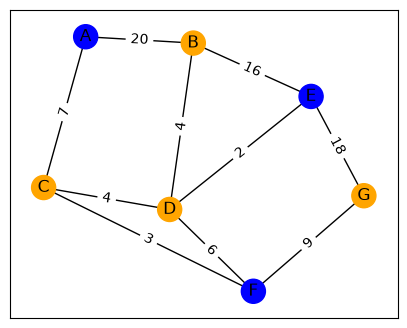

In [48]:
myEdges = {
    (u, v): d["weight"]
    for u, v, d in G.edges(data=True)
}
myVertices = G.nodes

solution = getMaxWeight(np.array(myVertices),myEdges)

colourMap = ["Orange" if x == 0 else "Blue" for x in solution[3]]

plt.figure(figsize=(5, 4))
# pos=nx.spring_layout(G) 
nx.draw_networkx(G, pos,node_color=colourMap)
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.show()

Graph test

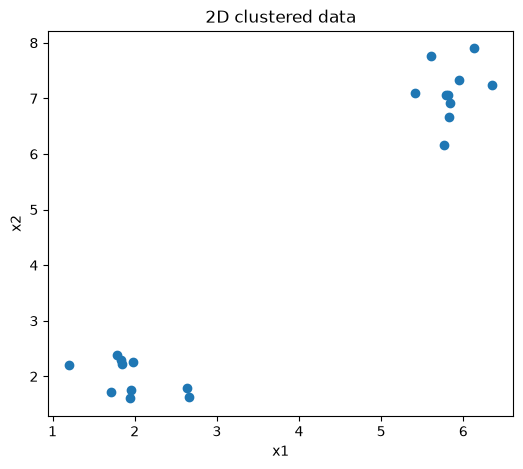

In [49]:
# np.random.seed(42)

# Three clusters in 2D
cluster1 = np.random.normal(loc=[2.0, 2.0], scale=[0.4, 0.5], size=(10, 2))
cluster2 = np.random.normal(loc=[6.0, 7.0], scale=[0.5, 0.4], size=(10, 2))
# cluster3 = np.random.normal(loc=[8.0, 2.5], scale=[0.6, 0.5], size=(35, 2))

X = np.concatenate((cluster1, cluster2))
np.random.shuffle(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('2D clustered data')
plt.show()


Now make a graph from these

In [50]:
G = nx.Graph()

# Add nodes with their coordinates
for i, point in enumerate(X):
    G.add_node(i, pos=(float(point[0]), float(point[1])))

# Add edges between every pair of points, weighted by Euclidean distance
for i in range(len(X)):
    for j in range(i + 1, len(X)):
        dist = np.linalg.norm(X[i] - X[j])
        G.add_edge(i, j, weight=float(dist))

# Optional: draw the graph
# pos = {i: tuple(point) for i, point in enumerate(X)}
# plt.figure(figsize=(6, 5))
# nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=25)
# nx.draw_networkx_edges(G, pos, width=1.0)
# nx.draw_networkx_labels(G, pos, font_size=8)
# plt.title("Complete distance-weighted graph")
# plt.axis("off")
# plt.show()

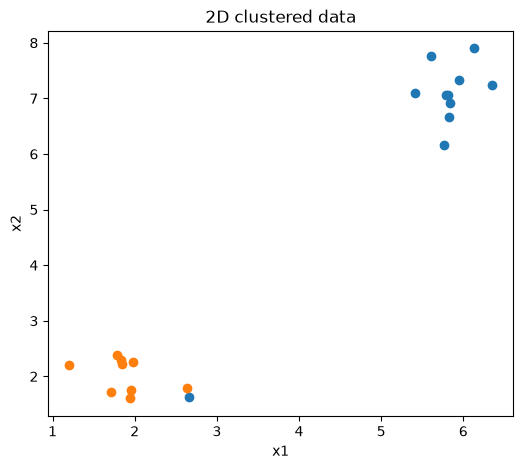

In [51]:
myEdges = {
    (u, v): d["weight"]
    for u, v, d in G.edges(data=True)
}
myVertices = G.nodes

solution = getMaxWeight(np.array(myVertices),myEdges)

plt.figure(figsize=(6, 5))
plt.scatter(X[solution[1],0], X[solution[1],1])
plt.scatter(X[solution[2],0], X[solution[2],1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('2D clustered data')
plt.show()

Now time to implement the SDP

In [52]:
def solve_maxcut_sdp(G, rho=None, max_iter=20_000,
                     abs_tol=1e-6, rel_tol=1e-5,
                     rounding_trials=1_000, seed=None):
    """Approximate the Max-Cut SDP with NumPy-only ADMM and round its solution."""
    # Index the graph's nodes so matrices and node labels can be used together.
    nodes = list(G.nodes)
    n = len(nodes)
    if n == 0:
        raise ValueError("G must contain at least one node")

    index = {node: i for i, node in enumerate(nodes)}

    # Collect edge weights and reject inputs outside the nonnegative Max-Cut model.
    edges = []
    weights = []
    for u, v, data in G.edges(data=True):
        weight = float(data.get("weight", 1.0))
        if weight < 0:
            raise ValueError("Max-Cut SDP requires nonnegative edge weights")
        edges.append((u, v, weight))
        weights.append(weight)

    # Choose a default ADMM penalty on the scale of the graph's edge weights.
    total_weight = sum(weights)
    if rho is None:
        rho = max(float(np.mean(weights)) if weights else 0.0, 1e-8)
    if rho <= 0:
        raise ValueError("rho must be positive")

    # Encode the SDP objective: max total_weight/2 + trace(C @ X),
    # subject to X being positive semidefinite with a unit diagonal.
    C = np.zeros((n, n), dtype=float)
    for u, v, weight in edges:
        i, j = index[u], index[v]
        C[i, j] -= weight / 4
        C[j, i] -= weight / 4

    # Initialize the primal matrix X, PSD copy Z, and scaled dual variable U.
    X = np.eye(n)
    Z = np.eye(n)
    U = np.zeros((n, n))
    converged = False

    # Alternate between enforcing the unit diagonal and PSD constraints.
    for iteration in range(1, max_iter + 1):
        # Update X for the linear objective, then enforce symmetry and diag(X)=1.
        X = Z - U + C / rho
        X = (X + X.T) / 2
        np.fill_diagonal(X, 1.0)

        # Project X + U onto the PSD cone by clipping negative eigenvalues.
        previous_Z = Z
        eigenvalues, eigenvectors = np.linalg.eigh((X + U + (X + U).T) / 2)
        Z = (eigenvectors * np.maximum(eigenvalues, 0.0)) @ eigenvectors.T
        Z = (Z + Z.T) / 2

        # Update the dual variable to track disagreement between X and Z.
        U += X - Z

        # Measure primal/dual disagreement and compute scale-aware tolerances.
        primal_residual = np.linalg.norm(X - Z, ord="fro")
        dual_residual = rho * np.linalg.norm(Z - previous_Z, ord="fro")
        eps_primal = n * abs_tol + rel_tol * max(
            np.linalg.norm(X, ord="fro"), np.linalg.norm(Z, ord="fro")
        )
        eps_dual = n * abs_tol + rel_tol * rho * np.linalg.norm(U, ord="fro")

        # Stop once both ADMM residuals are small enough.
        if primal_residual <= eps_primal and dual_residual <= eps_dual:
            converged = True
            break

    # Convert the PSD solution into vectors whose dot products approximate X.
    eigenvalues, eigenvectors = np.linalg.eigh((Z + Z.T) / 2)
    keep = eigenvalues > 1e-10
    factor = eigenvectors[:, keep] * np.sqrt(eigenvalues[keep])
    if factor.shape[1] == 0:
        factor = np.ones((n, 1))

    # Normalize each vector before projecting it onto random hyperplanes.
    row_norms = np.linalg.norm(factor, axis=1)
    factor = factor / np.maximum(row_norms[:, None], 1e-12)

    # Try random hyperplanes and retain the partition with the largest cut.
    rng = np.random.default_rng(seed)
    best_partition = None
    best_cut_value = -1.0
    for _ in range(rounding_trials):
        direction = rng.standard_normal(factor.shape[1])
        signs = factor @ direction >= 0
        partition = (
            [node for i, node in enumerate(nodes) if signs[i]],
            [node for i, node in enumerate(nodes) if not signs[i]],
        )
        cut_value = sum(
            weight for u, v, weight in edges
            if signs[index[u]] != signs[index[v]]
        )
        if cut_value > best_cut_value:
            best_cut_value = cut_value
            best_partition = partition

    # Report the SDP objective estimate, best rounded cut, and convergence status.
    sdp_bound = total_weight / 2 + float(np.sum(C * X))
    return {
        "matrix": Z,
        "sdp_bound": sdp_bound,
        "partition": best_partition,
        "cut_value": best_cut_value,
        "iterations": iteration,
        "converged": converged,
    }

Now see benefits

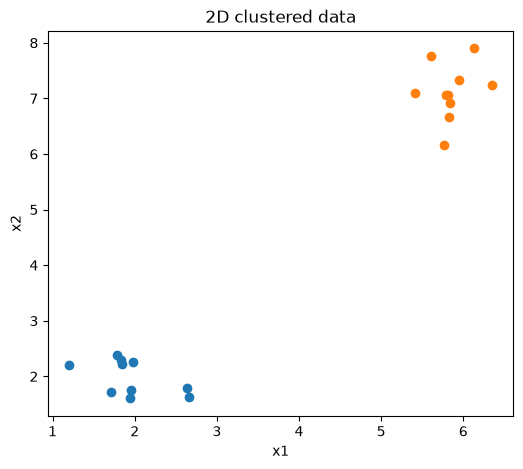

In [53]:
solution = solve_maxcut_sdp(G)

plt.figure(figsize=(6, 5))
plt.scatter(X[solution["partition"][0],0], X[solution["partition"][0],1])
plt.scatter(X[solution["partition"][1],0], X[solution["partition"][1],1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('2D clustered data')
plt.show()